In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import nltk

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

import spacy
nlp = spacy.load('en_core_web_sm')

pd.set_option('display.max_colwidth', None)

print("All imports successful ✓")

[nltk_data] Downloading package punkt_tab to /home/giuly/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/giuly/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/giuly/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/giuly/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


All imports successful ✓


In [ ]:
df = pd.read_csv('../data/processed/df_sunscreen_augmented.csv')
print(f"Shape: {df.shape}")
print(f"\nContent types:\n{df['content_type'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head(3)

In [20]:
# mark synthetic vs real
df['is_synthetic'] = df['text_clean'].isna()

In [21]:
# preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

custom_stopwords = {
    'people', 'one', 'think', 'thing', 'use', 'make', 'way', 'even',
    'dont', 'thats', 'isnt', 'doesnt', 'cant', 'im', 'youre', 'theyre', 'arent',
    'u', 'ye', 'etc', 'really', 'still', 'much', 'many', 'lot', 'well',
    'good', 'great', 'better', 'got', 'put', 'go', 'come', 'take', 'try',
    'say', 'feel', 'mean', 'seem', 'look', 'start', 'end', 'keep', 'would',
    'want', 'need', 'know', 'help', 'find', 'work', 'used', 'using',
    'something', 'anything', 'everything', 'nothing', 'someone', 'like', 'get',
    'also', 'back', 'around', 'first', 'every', 'never', 'always',
    'maybe', 'probably', 'though', 'already', 'enough', 'little',
    'stuff', 'see', 'going', 'sure', 'actually', 'co',
    'right', 'yes', 'yeah', 'me', 'said', 'saying', 'didnt', 'wont',
    'things', 'ive', 'time', 'point', 'thank', 'making'
}

stop_words_extended = stop_words | custom_stopwords

In [22]:
# creating a function for cleaning the text using the customized stopwords
def preprocess_text(text):
    if pd.isna(text):
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words_extended]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# preprocessing the data
print("Preprocessing...")
df['text_clean'] = df['Text'].apply(preprocess_text)
print(f"Done. Empty texts: {(df['text_clean'] == '').sum()}")

Preprocessing...
Done. Empty texts: 0


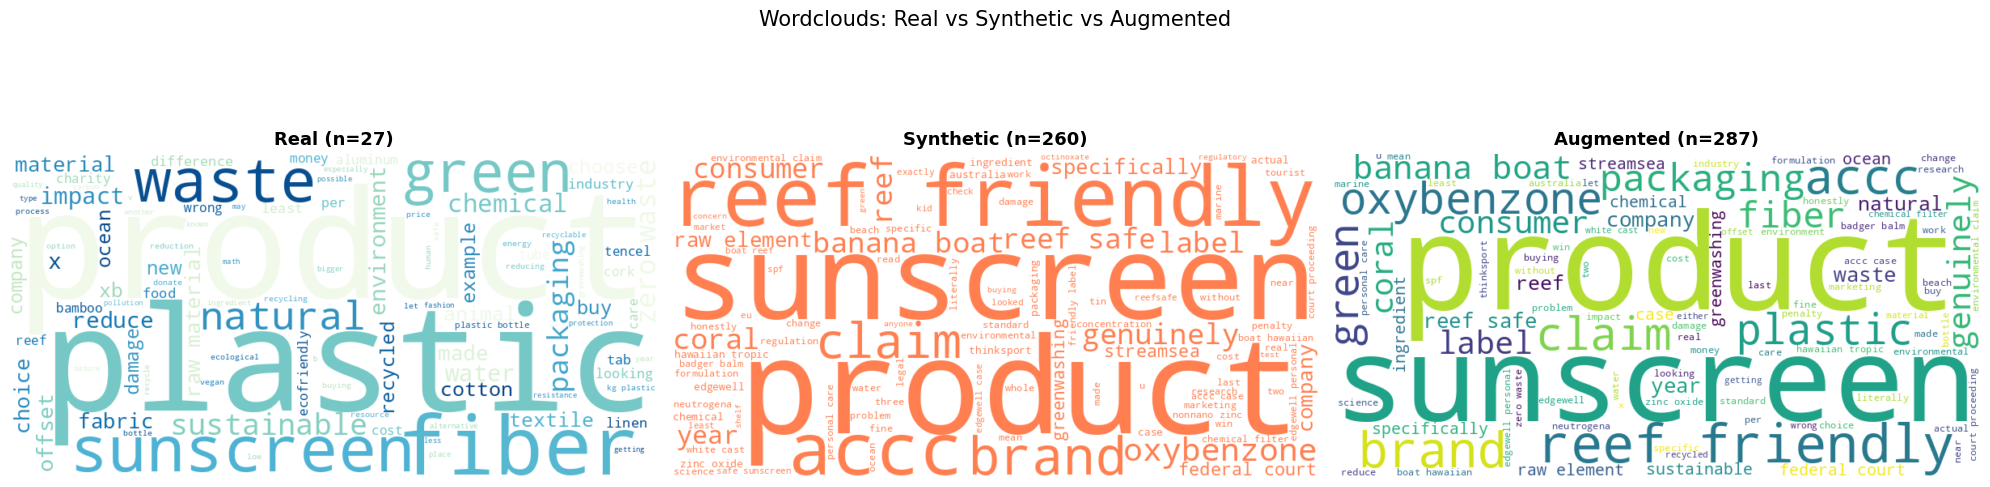

In [23]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

datasets = {
    'Real (n=27)': (df[df['is_synthetic']==False]['text_clean'], 'GnBu'),
    'Synthetic (n=260)': (df[df['is_synthetic']==True]['text_clean'], None),
    'Augmented (n=287)': (df['text_clean'], 'viridis')
}

for ax, (title, (texts, cmap)) in zip(axes, datasets.items()):
    text_all = ' '.join(texts)
    if cmap:
        wc = WordCloud(width=800, height=400, background_color='white',
                      colormap=cmap, max_words=100).generate(text_all)
    else:
        wc = WordCloud(width=800, height=400, background_color='white',
                      color_func=lambda *args, **kwargs: 'coral',
                      max_words=100).generate(text_all)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Wordclouds: Real vs Synthetic vs Augmented', fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
for label, texts, cmap, color in [
    ('real', df[df['is_synthetic']==False]['text_clean'], 'GnBu', None),
    ('synthetic', df[df['is_synthetic']==True]['text_clean'], None, 'coral'),
    ('augmented', df['text_clean'], 'viridis', None),
]:
    text_all = ' '.join(texts)
    if cmap:
        wc = WordCloud(width=800, height=500, background_color='white',
                      colormap=cmap, max_words=100).generate(text_all)
    else:
        wc = WordCloud(width=800, height=500, background_color='white',
                      color_func=lambda *args, **kwargs: color,
                      max_words=100).generate(text_all)
    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f'../figures/wordcloud_{label}.png', dpi=150, bbox_inches='tight')
    plt.close()
    print(f"✓ wordcloud_{label}.png saved")

## Wordcloud Analysis: Real vs Synthetic vs Augmented

Three wordclouds were generated to visually compare the vocabulary 
distribution across the real, synthetic, and augmented datasets.

**Real (n=27):** vocabulary is broader and less focused, dominated by 
generic sustainability terms (*fiber*, *plastic*, *product*, *natural*). 
Sunscreen is present but not dominant, reflecting the scarcity of 
brand-specific content in the original Reddit data.

**Synthetic (n=260):** vocabulary is sharply focused on the target topic: 
*reef*, *friendly*, *sunscreen*, *accc*, *banana boat*, *oxybenzone* 
all feature prominently. The synthetic data successfully introduced 
the brand-specific and regulatory signal that was m

In [24]:
# VADER is a rule-based sentiment analyzer designed for social media text
# it returns 4 scores: positive, negative, neutral, and compound
# compound is the overall score: ranges from -1 (most negative) to +1 (most positive)
# thresholds: compound >= 0.05 = positive, <= -0.05 = negative, in between = neutral

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    scores = sia.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_score'] = df['Text'].apply(lambda x: sia.polarity_scores(x)['compound'])
df['sentiment_label'] = df['Text'].apply(get_sentiment)

print(df['sentiment_label'].value_counts())
print(f"\nMean compound score: {df['sentiment_score'].mean():.3f}")

sentiment_label
positive    189
negative     76
neutral      22
Name: count, dtype: int64

Mean compound score: 0.263


## Sentiment Analysis with VADER

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based 
sentiment analyzer specifically designed for social media text. Unlike 
ML-based models, VADER uses a lexicon of words with pre-assigned valence 
scores and a set of grammatical rules to compute sentiment.

VADER was chosen for this analysis because:
- It is optimised for informal, short-form social media text (Reddit comments)
- It handles capitalisation, punctuation emphasis, and negations natively
- It requires no training data and no GPU — appropriate for a small dataset
- It is fast and interpretable

The compound score ranges from -1 (most negative) to +1 (most positive).
Classification thresholds follow the authors' official recommendation:
- compound >= 0.05 → positive
- compound <= -0.05 → negative
- otherwise → neutral

**Results:** 189 positive (65.9%), 76 negative (26.5%), 22 neutral (7.7%)
Mean compound score: 0.263

**Known limitation 1:** VADER does not detect sarcasm. Approximately 19% of 
the synthetic data (batch 5) was intentionally sarcastic — these entries 
may have been misclassified as positive, slightly inflating that count. 
This is a known limitation of lexicon-based sentiment analysis and would 
require a fine-tuned transformer model (e.g. RoBERTa) to address properly.

**Known limitation 2:** VADER lacks domain-specific context. 
Terms like "thick" or "white cast" are neutral in VADER's lexicon 
but carry positive or negative connotations depending on the 
reef-safe sunscreen context (e.g. "thick" may signal poor 
cosmetic elegance; "white cast" is a known drawback of mineral 
formulations). A domain-adapted model would handle these nuances better.

In [25]:
# NER - Named Entity Recognition
# we run spaCy on the original Text, not text_clean
# preprocessing removes capitalisation and proper nouns needed for NER

def extract_entities(text):
    if pd.isna(text):
        return []
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

print("Running NER...")
df['entities'] = df['Text'].apply(extract_entities)
print("Done!")

# quick look
df[['Text', 'entities']].sample(5)

Running NER...
Done!


,Text,entities
198,"I've been researching the regulatory landscape for sunscreen claims in different countries and the short version is: it's a mess everywhere but some places are less messy. Australia: no legal definition for reef safe/friendly, ACCC has taken some action on specific misleading claims (notably the Edgewell case in 2025). US: FDA regulates sunscreen as OTC drug but doesn't regulate environmental claims, which fall to FTC green guide guidelines that have no enforcement teeth. EU: moving toward stricter green claims regulation but not there yet. Hawaii and Palau: actual ingredient bans which are the most effective approach. Everyone else: chaos. The answer globally is ingredient bans, not label regulation, because labels can always be gamed.","[(Australia, GPE), (ACCC, PERSON), (Edgewell, PERSON), (2025, DATE), (US, GPE), (FDA, ORG), (FTC, ORG), (EU, ORG), (Hawaii, GPE), (Palau, GPE)]"
283,the consumer education effect of this case is huge. every news segment about it explains what oxybenzone is and why reef friendly is misleading. that reaches people who would never read a sustainability subreddit,[]
96,iron oxide tinted zinc sunscreens help a lot with the white cast on darker skin. Badger Balm now has a tinted version. Still not perfect but way better than standard white zinc,"[(Badger Balm, PERSON)]"
205,"I've started doing a rule at the pharmacy: if the packaging has any green colour, any ocean or nature imagery, or any eco-sounding words, I assume it's probably greenwashing until proven otherwise by the ingredient list. sad state of affairs",[]
87,Stream2Sea actually tests their finished products on coral larvae and publishes the results on their website. That level of transparency is what every sunscreen company should be doing.,[]


In [26]:
# add custom entity ruler for brand names
ruler = nlp.add_pipe('entity_ruler', before='ner')

patterns = [
    {'label': 'ORG', 'pattern': 'Banana Boat'},
    {'label': 'ORG', 'pattern': 'Hawaiian Tropic'},
    {'label': 'ORG', 'pattern': 'Stream2Sea'},
    {'label': 'ORG', 'pattern': 'Raw Elements'},
    {'label': 'ORG', 'pattern': 'Thinksport'},
    {'label': 'ORG', 'pattern': 'Badger Balm'},
    {'label': 'ORG', 'pattern': 'Sun Bum'},
    {'label': 'ORG', 'pattern': 'Neutrogena'},
    {'label': 'ORG', 'pattern': 'Coppertone'},
    {'label': 'ORG', 'pattern': 'Edgewell'},
    {'label': 'ORG', 'pattern': 'ACCC'},
]

ruler.add_patterns(patterns)
print("Entity ruler added ✓")

Entity ruler added ✓


In [27]:
print("Running NER...")
df['entities'] = df['Text'].apply(extract_entities)
print("Done!")

# quick look
df[['Text', 'entities']].sample(5)

Running NER...
Done!


,Text,entities
198,"I've been researching the regulatory landscape for sunscreen claims in different countries and the short version is: it's a mess everywhere but some places are less messy. Australia: no legal definition for reef safe/friendly, ACCC has taken some action on specific misleading claims (notably the Edgewell case in 2025). US: FDA regulates sunscreen as OTC drug but doesn't regulate environmental claims, which fall to FTC green guide guidelines that have no enforcement teeth. EU: moving toward stricter green claims regulation but not there yet. Hawaii and Palau: actual ingredient bans which are the most effective approach. Everyone else: chaos. The answer globally is ingredient bans, not label regulation, because labels can always be gamed.","[(Australia, GPE), (ACCC, ORG), (Edgewell, ORG), (2025, DATE), (US, GPE), (FDA, ORG), (FTC, ORG), (EU, ORG), (Hawaii, GPE), (Palau, GPE)]"
211,the distinction between vague aspirational greenwashing and specific false claims is really important and doesn't get made often enough. reef friendly is in the second category,"[(second, ORDINAL)]"
274,the years of marine scientists raising the alarm and being ignored and then seeing an ACCC Federal Court case filed must feel like something. finally being heard after nearly a decade,"[(the years, DATE), (ACCC, ORG), (Federal Court, ORG), (nearly a decade, DATE)]"
10,"You have some good suggestions from other users here. I’m based in the UK so may not be of much help. Re sunscreen though, don’t forsake your health in the name of reducing plastic waste. If you can only source or afford protection that is packaged in plastic you are still likely to be reducing waste long term by preventing yourself from becoming ill. I’m a bit wary of sunscreen that comes in tins although I’m sure some do work.","[(UK, GPE)]"
22,"While I share your attitude and efforts, this is one of those times where your health may take precedent over your environmental impact. Besides, chemical sunscreen itself has such a nasty impact on the environment (but again, in the absence of an alternative product that works for you, your health must be your priority) that a little plastic tube is really inconsequential.",[]


In [28]:
all_entities = []
for ents in df['entities']:
    all_entities.extend(ents)

In [29]:
# count by entity text and label
entity_counts_labeled = Counter([(ent[0], ent[1]) for ent in all_entities])
print("Top 30 entities with label:")
for (entity, label), count in entity_counts_labeled.most_common(30):
    print(f"  {label:10} {entity}: {count}")

Top 30 entities with label:
  ORG        ACCC: 82
  ORG        Edgewell: 53
  ORG        Thinksport: 35
  ORG        Banana Boat: 31
  ORG        Raw Elements: 25
  ORG        Hawaiian Tropic: 24
  ORG        Stream2Sea: 24
  ORG        Federal Court: 24
  CARDINAL   zero: 23
  GPE        Australia: 19
  CARDINAL   one: 18
  ORG        Badger Balm: 17
  ORG        EWG: 15
  GPE        Hawaii: 12
  ORG        Neutrogena: 12
  ORDINAL    first: 11
  GPE        US: 11
  DATE       years: 11
  ORG        EU: 10
  CARDINAL   two: 9
  NORP       Australian: 9
  CARDINAL   three: 8
  ORG        FDA: 7
  DATE       daily: 7
  CARDINAL   1: 6
  FAC        the Great Barrier Reef: 6
  ORG        Sun Bum: 6
  ORDINAL    third: 5
  PERCENT    100%: 5
  CARDINAL   2: 5


In [30]:
# flatten all entities into a single list and count
from collections import Counter

all_entities = []
for ents in df['entities']:
    all_entities.extend(ents)

# count by entity text
entity_counts = Counter([ent[0] for ent in all_entities])
print("Top 30 entities:")
for entity, count in entity_counts.most_common(30):
    print(f"  {entity}: {count}")

Top 30 entities:
  ACCC: 82
  Edgewell: 53
  Thinksport: 35
  Banana Boat: 31
  Raw Elements: 25
  Hawaiian Tropic: 24
  Stream2Sea: 24
  Federal Court: 24
  zero: 23
  Australia: 19
  one: 18
  Badger Balm: 17
  EWG: 15
  Hawaii: 12
  Neutrogena: 12
  first: 11
  US: 11
  years: 11
  EU: 10
  two: 9
  Australian: 9
  three: 8
  2: 7
  FDA: 7
  daily: 7
  1: 6
  the Great Barrier Reef: 6
  Sun Bum: 6
  third: 5
  100%: 5


In [31]:
# filter only relevant entity types: Organizations and Geo-Political Entities
relevant_labels = ['ORG', 'GPE']

filtered_entities = [(ent[0], ent[1]) for ent in all_entities if ent[1] in relevant_labels]
filtered_counts = Counter([ent[0] for ent in filtered_entities])

print("Top 20 ORG and GPE entities:")
for entity, count in filtered_counts.most_common(20):
    print(f"  {entity}: {count}")

Top 20 ORG and GPE entities:
  ACCC: 82
  Edgewell: 53
  Thinksport: 35
  Banana Boat: 31
  Raw Elements: 25
  Hawaiian Tropic: 24
  Stream2Sea: 24
  Federal Court: 24
  Australia: 19
  Badger Balm: 17
  EWG: 15
  Hawaii: 12
  Neutrogena: 12
  US: 11
  EU: 10
  FDA: 7
  Sun Bum: 6
  Palau: 5
  Coppertone: 5
  PLA: 4


In [32]:
# for each brand, find documents that mention it and get average sentiment
brands_of_interest = [
    'Banana Boat', 'Hawaiian Tropic', 'Neutrogena', 'Coppertone',  # greenwashing
    'Stream2Sea', 'Raw Elements', 'Thinksport', 'Badger Balm', 'Sun Bum'  # reef-safe
]

brand_sentiment = {}
for brand in brands_of_interest:
    mask = df['Text'].str.contains(brand, case=False, na=False)
    docs = df[mask]
    if len(docs) > 0:
        brand_sentiment[brand] = {
            'mean_sentiment': docs['sentiment_score'].mean(),
            'count': len(docs)
        }

brand_df = pd.DataFrame(brand_sentiment).T.reset_index()
brand_df.columns = ['brand', 'mean_sentiment', 'count']
brand_df['category'] = brand_df['brand'].apply(
    lambda x: 'Greenwashing' if x in ['Banana Boat', 'Hawaiian Tropic', 'Neutrogena', 'Coppertone'] 
    else 'Reef-safe'
)
brand_df = brand_df.sort_values('mean_sentiment')
print(brand_df)

             brand  mean_sentiment  count      category
3       Coppertone       -0.102360    5.0  Greenwashing
4       Stream2Sea        0.273423   26.0     Reef-safe
1  Hawaiian Tropic        0.355546   24.0  Greenwashing
0      Banana Boat        0.377316   37.0  Greenwashing
5     Raw Elements        0.414850   24.0     Reef-safe
2       Neutrogena        0.418915   13.0  Greenwashing
6       Thinksport        0.491958   31.0     Reef-safe
8          Sun Bum        0.538725    4.0     Reef-safe
7      Badger Balm        0.558276   17.0     Reef-safe


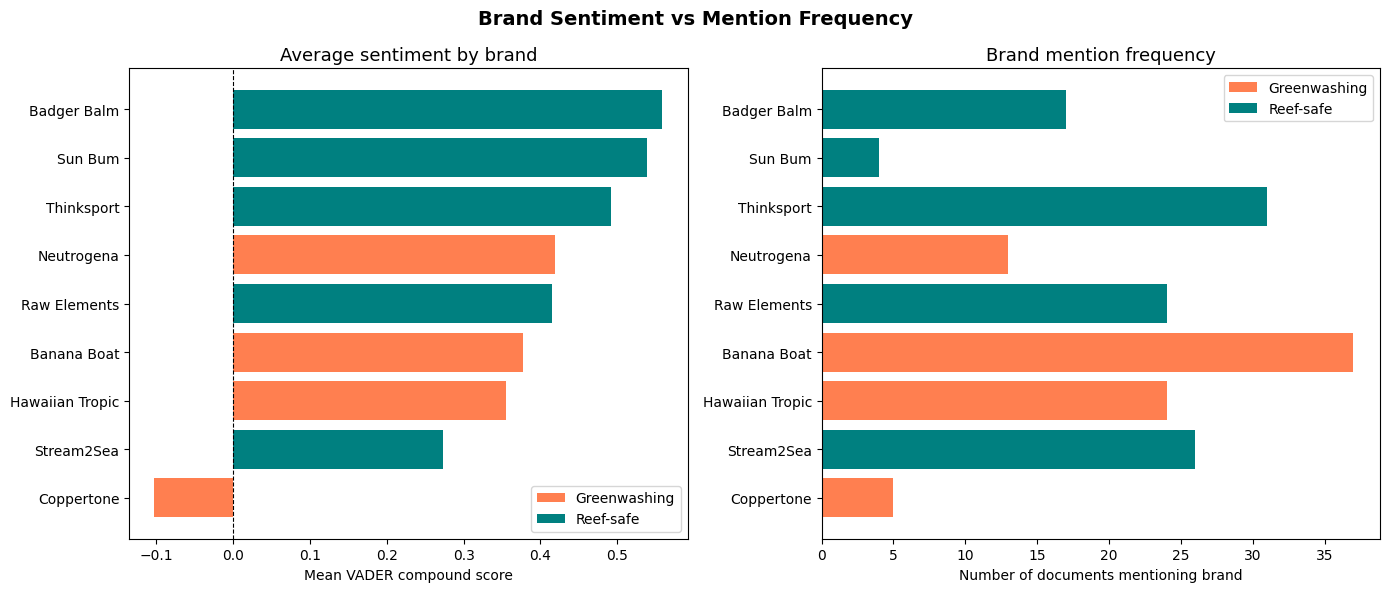

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {'Greenwashing': 'coral', 'Reef-safe': 'teal'}

# --- barplot brand sentiment ---
bar_colors = [colors[cat] for cat in brand_df['category']]

axes[0].barh(brand_df['brand'], brand_df['mean_sentiment'], color=bar_colors)
axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Mean VADER compound score')
axes[0].set_title('Average sentiment by brand', fontsize=13)

# add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='coral', label='Greenwashing'),
                   Patch(facecolor='teal', label='Reef-safe')]
axes[0].legend(handles=legend_elements)

# --- barplot document count ---
axes[1].barh(brand_df['brand'], brand_df['count'], color=bar_colors)
axes[1].set_xlabel('Number of documents mentioning brand')
axes[1].set_title('Brand mention frequency', fontsize=13)
axes[1].legend(handles=legend_elements)

plt.suptitle('Brand Sentiment vs Mention Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Documents mentioning ACCC/Edgewell/Federal Court: 75

Sentiment distribution:
sentiment_label
positive    54
negative    20
neutral      1
Name: count, dtype: int64

Mean compound score: 0.339


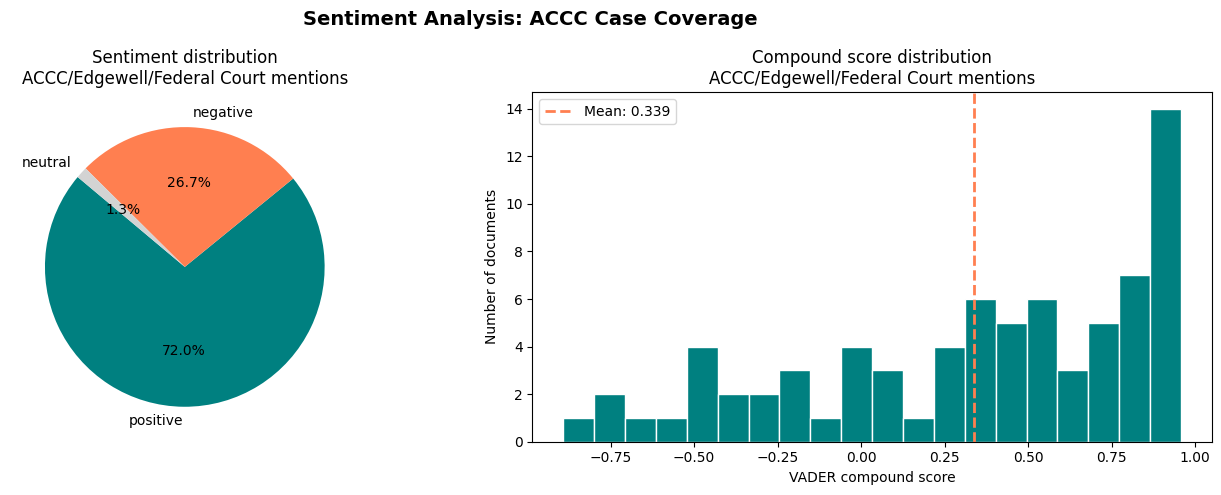

In [34]:
# filter documents mentioning ACCC
accc_mask = df['Text'].str.contains('ACCC|Edgewell|Federal Court', case=False, na=False)
df_accc = df[accc_mask].copy()

print(f"Documents mentioning ACCC/Edgewell/Federal Court: {len(df_accc)}")
print(f"\nSentiment distribution:")
print(df_accc['sentiment_label'].value_counts())
print(f"\nMean compound score: {df_accc['sentiment_score'].mean():.3f}")

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- pie chart sentiment distribution ---
sentiment_counts = df_accc['sentiment_label'].value_counts()
colors_pie = {'positive': 'teal', 'negative': 'coral', 'neutral': '#d3d3d3'}
pie_colors = [colors_pie[s] for s in sentiment_counts.index]

axes[0].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=140
)
axes[0].set_title('Sentiment distribution\nACCC/Edgewell/Federal Court mentions', fontsize=12)

# --- histogram of compound scores ---
axes[1].hist(df_accc['sentiment_score'], bins=20, color='teal', edgecolor='white')
axes[1].axvline(x=df_accc['sentiment_score'].mean(), color='coral', 
                linewidth=2, linestyle='--', label=f"Mean: {df_accc['sentiment_score'].mean():.3f}")
axes[1].set_xlabel('VADER compound score')
axes[1].set_ylabel('Number of documents')
axes[1].set_title('Compound score distribution\nACCC/Edgewell/Federal Court mentions', fontsize=12)
axes[1].legend()

plt.suptitle('Sentiment Analysis: ACCC Case Coverage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
# split ACCC documents by sentiment
df_accc_neg = df_accc[df_accc['sentiment_label'] == 'negative']
df_accc_pos = df_accc[df_accc['sentiment_label'] == 'positive']

# brands to look for
brands = ['Banana Boat', 'Hawaiian Tropic', 'Neutrogena', 'Coppertone',
          'Stream2Sea', 'Raw Elements', 'Thinksport', 'Badger Balm', 'Sun Bum']

# count brand mentions in negative vs positive ACCC docs
brand_neg = {}
brand_pos = {}

for brand in brands:
    brand_neg[brand] = df_accc_neg['Text'].str.contains(brand, case=False, na=False).sum()
    brand_pos[brand] = df_accc_pos['Text'].str.contains(brand, case=False, na=False).sum()

print("Brand mentions in NEGATIVE ACCC documents:")
for brand, count in sorted(brand_neg.items(), key=lambda x: x[1], reverse=True):
    if count > 0:
        print(f"  {brand}: {count}")

print("\nBrand mentions in POSITIVE ACCC documents:")
for brand, count in sorted(brand_pos.items(), key=lambda x: x[1], reverse=True):
    if count > 0:
        print(f"  {brand}: {count}")

Brand mentions in NEGATIVE ACCC documents:
  Banana Boat: 4
  Hawaiian Tropic: 3
  Stream2Sea: 1
  Raw Elements: 1

Brand mentions in POSITIVE ACCC documents:
  Banana Boat: 14
  Hawaiian Tropic: 13
  Raw Elements: 4
  Stream2Sea: 3
  Thinksport: 2


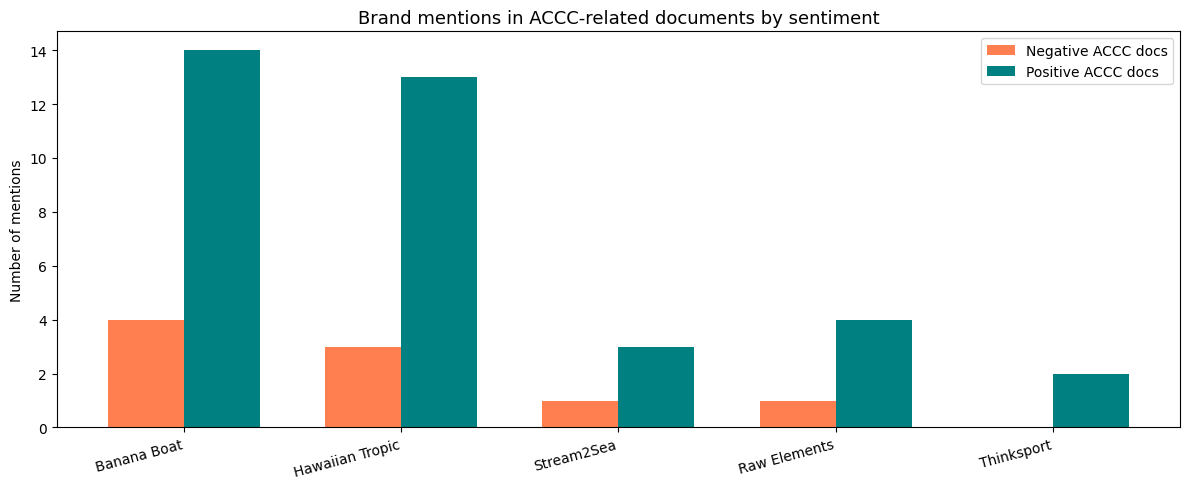

In [36]:
import numpy as np

brands_mentioned = ['Banana Boat', 'Hawaiian Tropic', 'Stream2Sea', 'Raw Elements', 'Thinksport']
neg_counts = [brand_neg[b] for b in brands_mentioned]
pos_counts = [brand_pos[b] for b in brands_mentioned]

x = np.arange(len(brands_mentioned))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - width/2, neg_counts, width, label='Negative ACCC docs', color='coral')
bars2 = ax.bar(x + width/2, pos_counts, width, label='Positive ACCC docs', color='teal')

ax.set_xticks(x)
ax.set_xticklabels(brands_mentioned, rotation=15, ha='right')
ax.set_ylabel('Number of mentions')
ax.set_title('Brand mentions in ACCC-related documents by sentiment', fontsize=13)
ax.legend()

plt.tight_layout()
plt.show()

In [37]:
# check the negative ACCC docs mentioning Stream2Sea
stream_neg_mask = (
    df_accc_neg['Text'].str.contains('Stream2Sea', case=False, na=False)
)
print(df_accc_neg[stream_neg_mask][['Text', 'sentiment_score', 'sentiment_label']].to_string())

                                                                                                                                                                                                                                               Text  sentiment_score sentiment_label
275  Stream2Sea was built by a marine toxicologist specifically because the greenwashing was so bad and nothing was being done about it. the fact that the ACCC case might vindicate everything she's been saying for years is genuinely satisfying          -0.2247        negative


In [38]:
# check all reef-safe brands in negative ACCC documents
reef_safe_brands = ['Stream2Sea', 'Raw Elements', 'Thinksport', 'Badger Balm', 'Sun Bum']

for brand in reef_safe_brands:
    mask = df_accc_neg['Text'].str.contains(brand, case=False, na=False)
    docs = df_accc_neg[mask]
    if len(docs) > 0:
        print(f"\n=== {brand} in NEGATIVE ACCC docs ===")
        print(docs[['Text', 'sentiment_score']].to_string())


=== Stream2Sea in NEGATIVE ACCC docs ===
                                                                                                                                                                                                                                               Text  sentiment_score
275  Stream2Sea was built by a marine toxicologist specifically because the greenwashing was so bad and nothing was being done about it. the fact that the ACCC case might vindicate everything she's been saying for years is genuinely satisfying          -0.2247

=== Raw Elements in NEGATIVE ACCC docs ===
                                                                                                                                                                                                                                                                                                                                                                                                        

### Qualitative Insight: Reef-safe Brands in Negative Documents

Manual inspection of the 2 negative ACCC-related documents mentioning 
reef-safe brands reveals a consistent pattern:

- **Stream2Sea** appears in a document critical of the greenwashing 
  industry, cited as a brand built specifically to address the problem
- **Raw Elements** appears in a document expressing betrayal toward 
  Banana Boat, cited as the trusted alternative after switching

In both cases, negative sentiment is directed toward greenwashing brands 
and the regulatory failure — not toward the reef-safe brands themselves. 
This suggests that reef-safe brands benefit from negative sentiment 
toward competitors: consumer anger at greenwashing directly drives 
consideration of genuine alternatives.

**This is the key strategic insight for Stream2Sea.**

In [39]:
# check what's actually said about Stream2Sea in the dataset
stream_mask = df['Text'].str.contains('Stream2Sea', case=False, na=False)
print(df[stream_mask][['Text', 'is_synthetic']].to_string())

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       Text  is_synthetic
27                                                                              ACCC just dropped the hammer on Banana Boat and Hawaiian Tropic - Federal Court proceedings for greenwashing!! Finally someone is doing something about these 'reef friendly' 

In [ ]:
df.to_csv('../data/processed/df_sunscreen_final.csv', index=False)
print(f"✓ Saved: {df.shape}")

## Conclusions

### Methodological Limitations

Sentiment analysis was performed using VADER, a rule-based lexicon 
designed for social media text. While appropriate for informal Reddit 
content, VADER has two key limitations relevant to this dataset:

1. **Sarcasm detection**: VADER cannot distinguish sarcastic positivity 
   from genuine positivity. Approximately 19% of synthetic data (batch 5) 
   was intentionally sarcastic, which likely inflated positive sentiment counts.

2. **Domain-specific context**: terms like "thick" or "white cast" carry 
   connotations specific to the reef-safe sunscreen domain that VADER's 
   general lexicon cannot capture.

A transformer-based model (e.g. RoBERTa fine-tuned on social media sentiment) 
would address both limitations but requires GPU resources not available 
in the current environment.

### NER Results

Named Entity Recognition was performed using spaCy (en_core_web_sm), 
augmented with a custom Entity Ruler for brand names not present in 
the pre-trained model. Only ORG and GPE entities were retained for 
downstream analysis.

Top entities by mention frequency: ACCC (82), Edgewell (53), 
Thinksport (35), Banana Boat (31), Stream2Sea (24), Raw Elements (25).

### Sentiment by Brand

Reef-safe brands (Stream2Sea, Raw Elements, Thinksport, Badger Balm, 
Sun Bum) show consistently higher sentiment scores and appear 
predominantly in positive documents. Greenwashing brands (Banana Boat, 
Hawaiian Tropic) dominate both negative and positive ACCC-related 
documents — the positive component likely reflects sarcastic framing 
misclassified by VADER.

### ACCC Case Sentiment

75 documents mention the ACCC case, Edgewell, or Federal Court proceedings. 
The compound score distribution is bimodal: a left peak reflecting 
genuine negative sentiment toward greenwashing brands, and a right peak reflecting 
a mix of genuine support for regulatory action and sarcastic positivity. 
Mean compound score: 0.339.

### Qualitative Insight: Reef-safe Brands in Negative Documents

Manual inspection of negative ACCC-related documents mentioning reef-safe 
brands reveals a consistent pattern: negative sentiment is never directed 
toward reef-safe brands themselves, but toward greenwashing brands and 
regulatory failure. Stream2Sea and Raw Elements appear as trusted 
alternatives in documents expressing consumer betrayal toward Banana Boat 
and Edgewell Personal Care.

This suggests that consumer anger at greenwashing directly drives 
consideration of genuine alternatives.

### Key Finding for Stream2Sea

Stream2Sea appears predominantly in positive contexts across the dataset. 
In negative ACCC-related documents, it is cited as a trusted alternative 
built specifically to address greenwashing — never as the target of criticism. 
This positions Stream2Sea as the natural beneficiary of growing consumer 
distrust toward Banana Boat and Hawaiian Tropic following the ACCC proceedings.

### Strategic Implications for Stream2Sea

The ACCC case has created a market opportunity that Stream2Sea is 
uniquely positioned to capture. The data shows three converging signals:

1. **Brand damage at scale**: Banana Boat is the most mentioned brand 
   in the dataset (37 documents), predominantly in the context of 
   ACCC proceedings and greenwashing accusations. Consumer trust in 
   Edgewell brands is actively eroding.

2. **Consideration shift**: in documents expressing betrayal toward 
   greenwashing brands, Stream2Sea is among the most cited alternatives. 
   Consumer anger at greenwashing directly drives consideration of 
   genuine alternatives.

3. **Sentiment consistency**: Stream2Sea appears in negative ACCC-related 
   documents only as a contrast to greenwashing, never as the target 
   of criticism. This pattern is consistent across the dataset.

**Note:** the synthetic nature of most Stream2Sea mentions (26 of 27 
documents) means these findings are indicative rather than conclusive. 
Replication with real scraped data from Reddit, TikTok and e-commerce 
platforms would be needed to validate the strategic implications.

## Future Work

### 1. Improved Sentiment Analysis with RoBERTa

VADER's limitations with sarcasm and domain-specific context could be 
addressed with a transformer-based model such as 
`cardiffnlp/twitter-roberta-base-sentiment`, fine-tuned on social media 
text. This would require GPU resources (tested on Google Colab or a 
higher-spec machine) but would produce significantly more accurate 
sentiment classification, particularly for the sarcastic content 
identified in this dataset.

### 2. Longitudinal Sentiment Analysis

The current dataset provides a snapshot of public sentiment in 2025, 
centred around the ACCC case. With real Reddit data collected over time, 
it would be possible to track how sentiment toward greenwashing brands 
and reef-safe alternatives has evolved, in particular before and after 
key regulatory events such as the Hawaii oxybenzone ban (2021) and the 
ACCC Federal Court proceedings (July 2025).

### 3. Platform-specific Data Collection and Targeted Marketing

Reddit provides a valuable but demographically skewed sample. 
Web scraping data from TikTok, Instagram, Facebook, and e-commerce 
review platforms (e.g. Amazon, Sephora) would enable demographic 
segmentation of the conversation. Different generations engage with 
sustainability content differently and on different platforms: 
a Gen Z audience on TikTok requires different messaging than 
Millennials on Instagram or Boomers on Facebook. 
This segmentation would allow Stream2Sea to develop platform-specific 
communication strategies based on real consumer data.

### 4. Aspect-based Sentiment Analysis

Rather than document-level sentiment, aspect-based sentiment analysis 
would allow attribution of sentiment to specific entities within the 
same document: distinguishing, for example, anger toward Banana Boat 
from praise for Stream2Sea within the same post. This would produce 
a more accurate brand sentiment profile.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.patches import Patch

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#F5F9FA')

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── KPI BAR ──────────────────────────────────────────────────────
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.set_facecolor('#1A2E35')
ax_kpi.axis('off')

kpis = [
    ("10.5%", "Greenwashing topic\nin full dataset"),
    ("287", "Total documents\n(real + synthetic)"),
    ("75", "ACCC-related\ndocuments"),
    ("65.9%", "Positive sentiment\n(VADER)"),
    ("82", "ACCC mentions\n(top NER entity)"),
]

for i, (val, label) in enumerate(kpis):
    x = 0.1 + i * 0.2
    ax_kpi.text(x, 0.65, val, transform=ax_kpi.transAxes,
                fontsize=26, fontweight='bold', color='#028090',
                ha='center', va='center')
    ax_kpi.text(x, 0.2, label, transform=ax_kpi.transAxes,
                fontsize=20, color='#028090',
                ha='center', va='center')


# ── BRAND SENTIMENT ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0])
ax1.set_facecolor('white')

colors_bar = ['coral' if c == 'Greenwashing' else 'teal'
              for c in brand_df['category']]
bars = ax1.barh(brand_df['brand'], brand_df['mean_sentiment'],
                color=colors_bar, height=0.6)
ax1.axvline(x=0, color='#1A2E35', linewidth=0.8, linestyle='--')
ax1.set_xlabel('Mean VADER compound score', fontsize=10, color='#64748B')
ax1.set_title('Average Sentiment by Brand', fontsize=12,
              fontweight='bold', color='#1A2E35', pad=8)
ax1.tick_params(colors='#64748B', labelsize=9)
ax1.spines[['top', 'right']].set_visible(False)
legend_elements = [Patch(facecolor='coral', label='Greenwashing'),
                   Patch(facecolor='teal', label='Reef-safe')]
ax1.legend(handles=legend_elements, fontsize=9)

# ── BRAND MENTION FREQUENCY ───────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 1])
ax2.set_facecolor('white')

ax2.barh(brand_df['brand'], brand_df['count'],
         color=colors_bar, height=0.6)
ax2.set_xlabel('Number of documents', fontsize=10, color='#64748B')
ax2.set_title('Brand Mention Frequency', fontsize=12,
              fontweight='bold', color='#1A2E35', pad=8)
ax2.tick_params(colors='#64748B', labelsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(handles=legend_elements, fontsize=9)

# ── ACCC PIE CHART ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
ax3.set_facecolor('white')

sentiment_counts = df_accc['sentiment_label'].value_counts()
pie_colors = {'positive': 'teal', 'negative': 'coral', 'neutral': '#d3d3d3'}
colors_pie = [pie_colors[s] for s in sentiment_counts.index]

ax3.pie(sentiment_counts.values,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        colors=colors_pie,
        startangle=140,
        textprops={'fontsize': 10})
ax3.set_title('ACCC Case: Sentiment Distribution\n(n=75 documents)',
              fontsize=12, fontweight='bold', color='#1A2E35', pad=8)

# ── ACCC HISTOGRAM ────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
ax4.set_facecolor('white')

ax4.hist(df_accc['sentiment_score'], bins=20,
         color='teal', edgecolor='white', alpha=0.85)
ax4.axvline(x=df_accc['sentiment_score'].mean(),
            color='coral', linewidth=2, linestyle='--',
            label=f"Mean: {df_accc['sentiment_score'].mean():.3f}")
ax4.set_xlabel('VADER compound score', fontsize=10, color='#64748B')
ax4.set_ylabel('Number of documents', fontsize=10, color='#64748B')
ax4.set_title('ACCC Case: Compound Score Distribution\n(bimodal — anger vs support)',
              fontsize=12, fontweight='bold', color='#1A2E35', pad=8)
ax4.spines[['top', 'right']].set_visible(False)
ax4.tick_params(colors='#64748B', labelsize=9)
ax4.legend(fontsize=9)

plt.savefig('../figures/dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#F5F9FA')
plt.show()
print("✓ Dashboard saved as ../figures/dashboard.png")